In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import ast
import random
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv("news_multilabel.csv")
df["labels"] = df["labels"].apply(ast.literal_eval)

# =========================
# FILTER LABEL (3 kelas)
# =========================
allowed = ['ganjar_group', 'prabowo_gibran_group', 'anies_cak_imin_group']
df = df[df['labels'].apply(lambda x: x[0] in allowed)]

label2id = {l:i for i,l in enumerate(allowed)}
id2label = {i:l for l,i in label2id.items()}

df['label_id'] = df['labels'].apply(lambda x: label2id[x[0]])

print("\n=== DISTRIBUSI AWAL ===")
print({id2label[k]:v for k,v in Counter(df['label_id']).items()})


=== DISTRIBUSI AWAL ===
{'ganjar_group': 4024, 'prabowo_gibran_group': 3874, 'anies_cak_imin_group': 2108}


In [3]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label_id'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=42
)

print("\n=== TRAIN ===")
print({id2label[k]:v for k,v in Counter(train_df['label_id']).items()})

print("\n=== VALIDATION ===")
print({id2label[k]:v for k,v in Counter(val_df['label_id']).items()})

print("\n=== TEST ===")
print({id2label[k]:v for k,v in Counter(test_df['label_id']).items()})


=== TRAIN ===
{'anies_cak_imin_group': 1686, 'prabowo_gibran_group': 3099, 'ganjar_group': 3219}

=== VALIDATION ===
{'ganjar_group': 402, 'anies_cak_imin_group': 211, 'prabowo_gibran_group': 388}

=== TEST ===
{'prabowo_gibran_group': 387, 'ganjar_group': 403, 'anies_cak_imin_group': 211}


In [4]:
def random_deletion(words, p=0.1):
    return [w for w in words if random.random() > p] if len(words) > 3 else words

def random_swap(words):
    if len(words) < 2:
        return words
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return words

def augment_text(text):
    words = text.split()
    if random.random() < 0.5:
        words = random_deletion(words)
    else:
        words = random_swap(words)
    return " ".join(words)

In [5]:
counts = Counter(train_df['label_id'])
max_count = int(max(counts.values()) * 0.8)  # semi-balance

augmented = []

for label, count in counts.items():
    subset = train_df[train_df['label_id'] == label]
    needed = max_count - count

    if needed > 0:
        samples = subset.sample(n=min(len(subset), needed), replace=True)

        for _, row in samples.iterrows():
            augmented.append({
                "article_text": augment_text(row['article_text']),
                "label_id": row['label_id']
            })

In [6]:

train_df = pd.concat([train_df, pd.DataFrame(augmented)], ignore_index=True)

print("\n=== TRAIN AFTER AUGMENT ===")
print({id2label[k]:v for k,v in Counter(train_df['label_id']).items()})



=== TRAIN AFTER AUGMENT ===
{'anies_cak_imin_group': 2575, 'prabowo_gibran_group': 3099, 'ganjar_group': 3219}


In [7]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
MAX_LEN = 256

class NewsDataset(Dataset):
    def __init__(self, df):
        self.texts = df['article_text'].tolist()
        self.labels = df['label_id'].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(NewsDataset(train_df), batch_size=8, shuffle=True)
val_loader   = DataLoader(NewsDataset(val_df), batch_size=8)
test_loader  = DataLoader(NewsDataset(test_df), batch_size=8)

In [8]:
class IndoBERTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(768, 3)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IndoBERTClassifier().to(device)

In [9]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

In [10]:
class EarlyStopping:
    def __init__(self, patience=2):
        self.patience = patience
        self.counter = 0
        self.best = None
        self.stop = False

    def __call__(self, val_loss):
        if self.best is None or val_loss < self.best:
            self.best = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

early = EarlyStopping()

train_losses, val_losses, val_f1_scores = [], [], []

In [11]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0
    val_preds, val_true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_f1 = f1_score(val_true, val_preds, average='macro')

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)

    print(f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f} | F1 {val_f1:.4f}")

    early(val_loss)
    if early.stop:
        print("Early stopping")
        break

100%|██████████| 1112/1112 [02:37<00:00,  7.08it/s]


Epoch 1 | Train 0.3570 | Val 0.2248 | F1 0.9196


100%|██████████| 1112/1112 [02:32<00:00,  7.30it/s]


Epoch 2 | Train 0.2329 | Val 0.2053 | F1 0.9286


100%|██████████| 1112/1112 [02:31<00:00,  7.34it/s]


Epoch 3 | Train 0.1896 | Val 0.2448 | F1 0.9239


100%|██████████| 1112/1112 [02:34<00:00,  7.22it/s]


Epoch 4 | Train 0.1522 | Val 0.2387 | F1 0.9143
Early stopping


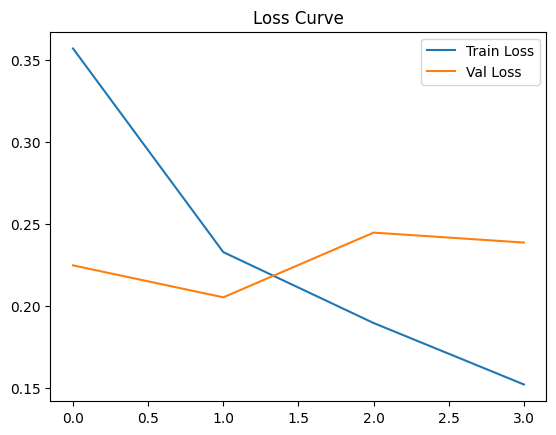

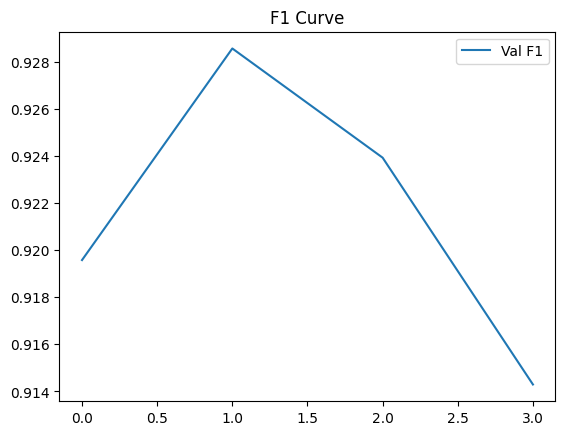

In [12]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(val_f1_scores, label='Val F1')
plt.legend()
plt.title("F1 Curve")
plt.show()

In [13]:
model.eval()
preds, trues = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask)
        pred = torch.argmax(outputs, dim=1).cpu().numpy()

        preds.extend(pred)
        trues.extend(batch['labels'].numpy())

print("\nF1 Macro:", f1_score(trues, preds, average='macro'))
print(classification_report(trues, preds, target_names=allowed))



F1 Macro: 0.9116238088215095
                      precision    recall  f1-score   support

        ganjar_group       0.89      0.95      0.92       403
prabowo_gibran_group       0.94      0.88      0.91       387
anies_cak_imin_group       0.91      0.91      0.91       211

            accuracy                           0.91      1001
           macro avg       0.91      0.91      0.91      1001
        weighted avg       0.91      0.91      0.91      1001



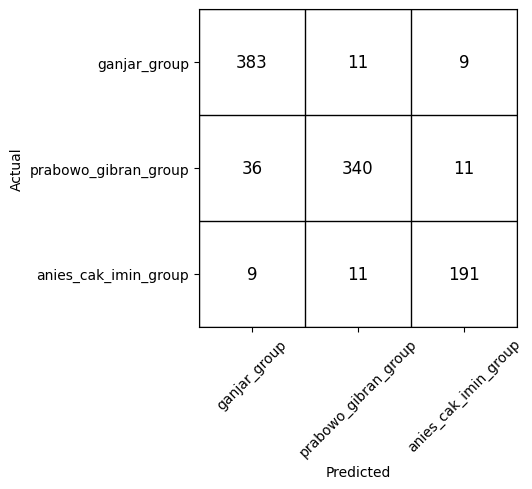

In [14]:
cm = confusion_matrix(trues, preds)

fig, ax = plt.subplots(figsize=(6,5))

# background putih
ax.imshow(np.ones_like(cm), cmap='gray', vmin=0, vmax=1)

# ticks
ax.set_xticks(np.arange(len(allowed)))
ax.set_yticks(np.arange(len(allowed)))

ax.set_xticklabels(allowed, rotation=45)
ax.set_yticklabels(allowed)

# 🔥 GRID RAPI PER CELL
ax.set_xticks(np.arange(-.5, len(allowed), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(allowed), 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=1)

ax.tick_params(which='minor', bottom=False, left=False)

# angka
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="black", fontsize=12)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()